In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install ultralytics

# What is pip?
# Think of it like Play Store.
# Instead of downloading mobile apps,
# it downloads Python packages.

In [3]:
from ultralytics import YOLO
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd

**ultralytics** Contains YOLO model


1.   *TensorFlow* contains *AI*
2.   *Ultralytics* contains *YOLO*
3.   *os* Helps Python work with folders.
    Example - ***os.listdir(folder)***
    returns - image1.jpg, image2.jpg,
4.    *cv2* - OpenCV Used for reading images, drawing rectangles, reading videos
5. matplotlib - Displays images

In [4]:
# Check GPU
import torch
print(torch.cuda.is_available())

True


**What is GPU?**

Suppose You have 1000 images.

CPU processes one image after another.

GPU processes hundreds together.

In [5]:
!nvidia-smi

Fri Jul 17 17:17:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P8             15W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
dataset_path="/content/drive/My Drive/RoadShield-AI/dataset/pothole_dataset"

In [7]:
import os

print(os.listdir(dataset_path))


['train', 'valid', 'test', 'data.yaml', 'README.dataset.txt']


In [8]:
# Understand data.yaml
import yaml
yaml_path=os.path.join(dataset_path,"data.yaml")

with open(yaml_path) as file:
    config=yaml.safe_load(file)

config

{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 1,
 'names': ['pothole'],
 'roboflow': {'workspace': 'aegis',
  'project': 'pothole-detection-i00zy',
  'version': 8,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/aegis/pothole-detection-i00zy/dataset/8'}}

**val** - Validation images

Used to check whether AI is improving.

**Teacher analogy**

Student studies

↓

Teacher takes test

↓

Gets marks

Validation is the test.

**test** - Final examination.

**nc** - Number of classes

You have only Pothole.
Therefore -> nc = 1

In [9]:
model=YOLO("yolov8n.pt")

In [10]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


**What is Pretrained?**

Imagine, you want to teach someone what a pothole looks like.
Instead of teaching from birth, you choose someone who already knows Cars, Roads, Humans, Trees, Traffic Lights.

Now, you teach only potholes. Much faster.

That person = Pretrained model.
YOLO already knows millions of objects.
Now, we teach one more object - Pothole.

In [11]:
results=model.train(
    data=yaml_path,
    epochs=4,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/RoadShield-AI/models",
    name="yolov8_pothole"
)

Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/My Drive/RoadShield-AI/dataset/pothole_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=4, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_pothole-2, nbs=64, nms=False, opset=N

In [12]:
project="/content/drive/My Drive/RoadShield-AI/models"

In [13]:
name="yolov8_pothole"

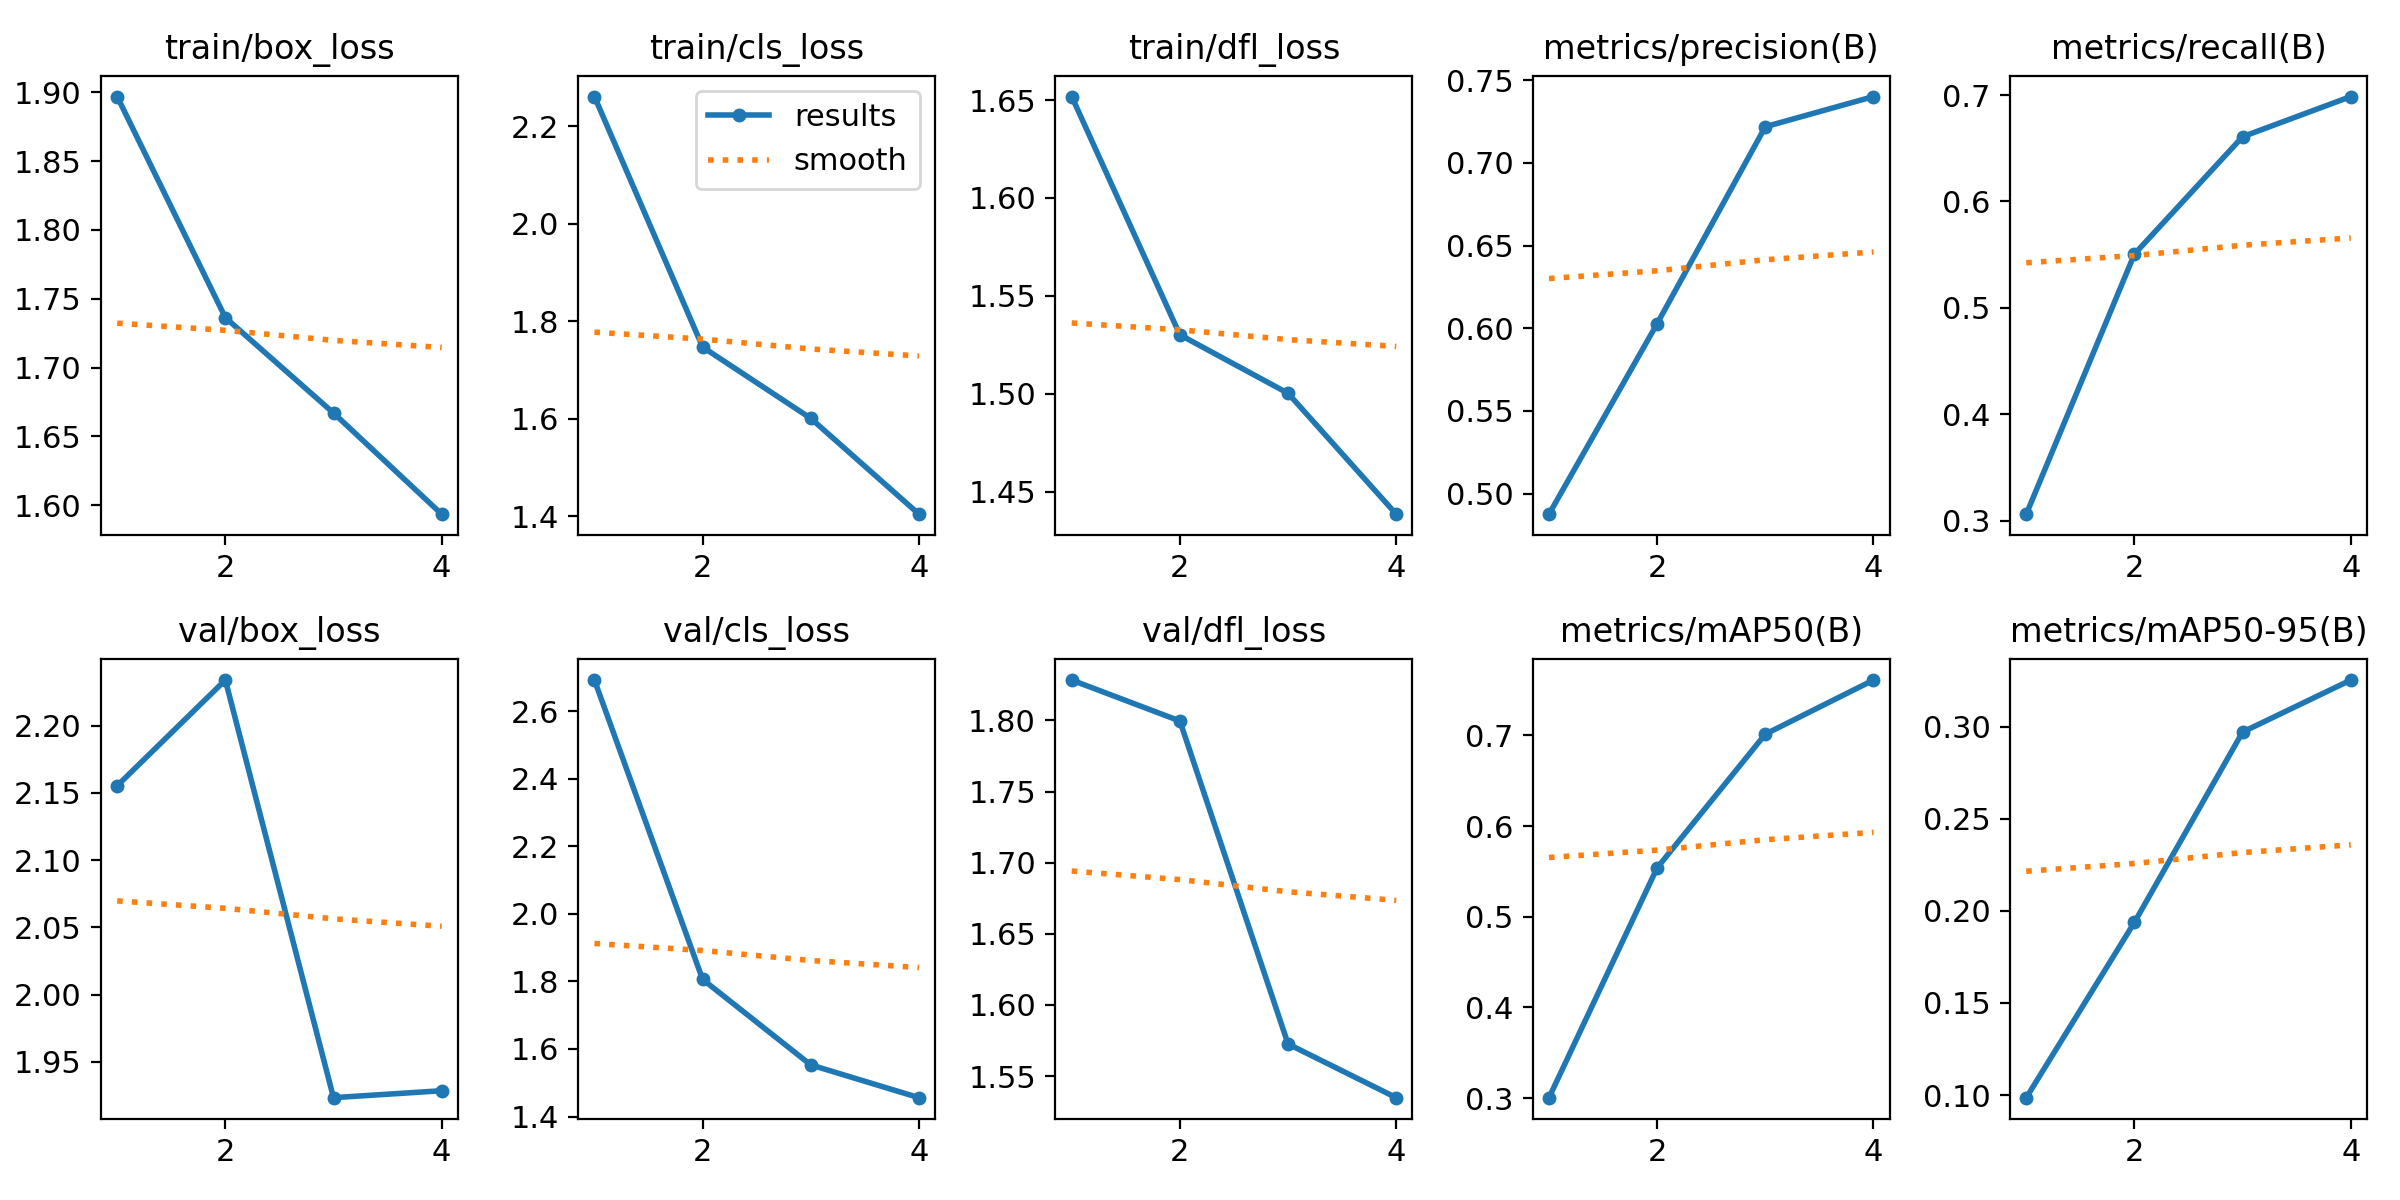

In [17]:
from IPython.display import Image

Image("/content/drive/MyDrive/RoadShield-AI/models/yolov8_pothole-2/results.png")